# Florida storm outage recovery forecasting: basic TFT vs persistence

This notebook loads the saved Florida transient files from `data_transients`, prepares an event-hour panel, trains a basic Temporal Fusion Transformer, and compares it against a simple persistence baseline on 24, 48, and 72 hour horizons.

The first version is intentionally simple. It uses the final 72-hour cut per series for the TFT evaluation. The rolling-origin persistence table is loaded separately as the operational benchmark reference.


## 1) Setup

If the environment does not already have the forecasting libraries, install them first.


In [2]:
# Optional install cell. Uncomment if needed in a fresh environment.
# pip install pytorch-forecasting lightning torchmetrics pyarrow pandas numpy scikit-learn matplotlib

# most useful for me given my weird python/pip situation (i dont really understand)
# python -m pip install --user pytorch-forecasting lightning torchmetrics pyarrow pandas numpy scikit-learn matplotlib


In [3]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore')

try:
    import lightning.pytorch as pl
except ImportError:  # fallback for older installs
    import pytorch_lightning as pl

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2) Paths and inputs

All file paths are read from `data_transients`, so this notebook does not depend on variables from the previous session.


In [4]:
BASE = Path(r'C:\Users\teaching\Downloads\outage-recovery-forecasting')
TRANSIENTS = BASE / 'data_transients'

MODEL_PATH = TRANSIENTS / 'florida_model_df.parquet'
EVENT_MASTER_PATH = TRANSIENTS / 'florida_event_master.parquet'
COVERAGE_PATH = TRANSIENTS / 'florida_coverage.parquet'
ROLLING_PERSIST_PATH = TRANSIENTS / 'florida_rolling_persistence_eval.parquet'

MODEL_PATH, EVENT_MASTER_PATH, COVERAGE_PATH, ROLLING_PERSIST_PATH


(WindowsPath('C:/Users/teaching/Downloads/outage-recovery-forecasting/data_transients/florida_model_df.parquet'),
 WindowsPath('C:/Users/teaching/Downloads/outage-recovery-forecasting/data_transients/florida_event_master.parquet'),
 WindowsPath('C:/Users/teaching/Downloads/outage-recovery-forecasting/data_transients/florida_coverage.parquet'),
 WindowsPath('C:/Users/teaching/Downloads/outage-recovery-forecasting/data_transients/florida_rolling_persistence_eval.parquet'))

## 3) Load the transient tables


In [5]:
model_df = pd.read_parquet(MODEL_PATH)
event_master = pd.read_parquet(EVENT_MASTER_PATH)
coverage_df = pd.read_parquet(COVERAGE_PATH)
rolling_persist_eval_df = pd.read_parquet(ROLLING_PERSIST_PATH)

print(model_df.shape)
print(event_master.shape)
print(coverage_df.shape)
print(rolling_persist_eval_df.shape)

model_df.head()


(17510, 22)
(99, 5)
(99, 9)
(35300, 12)


,event_id,storm,geoid,county,datetime,event_start,duration_hours,gust_mps,wind_speed_mps,precip_mm,...,CountyFIPS,outageFraction,customersTracked,persistence_1h,error,abs_error,sq_error,persistence_24h,persistence_48h,persistence_72h
0,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 15:00:00,2017-09-11 03:00:00,134,9.545648,6.145859,2.925622,...,12001,0.046551,97979.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 16:00:00,2017-09-11 03:00:00,134,10.602325,7.331592,3.961323,...,12001,0.043928,97979.0,0.046551,-0.002623,0.002623,0.000007,NaN,NaN,NaN
2,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 17:00:00,2017-09-11 03:00:00,134,12.677439,7.569997,3.951933,...,12001,0.011002,97979.0,0.043928,-0.032925,0.032925,0.001084,NaN,NaN,NaN
3,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 18:00:00,2017-09-11 03:00:00,134,13.805998,7.402843,3.323243,...,12001,0.003011,97979.0,0.011002,-0.007992,0.007992,0.000064,NaN,NaN,NaN
4,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 19:00:00,2017-09-11 03:00:00,134,18.680332,8.316379,3.520969,...,12001,0.010880,97979.0,0.003011,0.007869,0.007869,0.000062,NaN,NaN,NaN


## 4) Basic cleaning and feature engineering

The modelling unit is one county-event trajectory. We keep county codes as 5-digit strings and create a per-series time index in hours from event start.


In [7]:
df = model_df.copy()

# Standardize county identifiers.
if 'CountyFIPS' in df.columns:
    df['CountyFIPS'] = df['CountyFIPS'].astype(str).str.zfill(5)
if 'geoid' in df.columns:
    df['geoid'] = df['geoid'].astype(str).str.zfill(5)

# Make sure datetime fields are real timestamps.
for col in ['datetime', 'event_start']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Create a stable series id. Prefer event_id + CountyFIPS when available.
if 'CountyFIPS' in df.columns:
    df['series_id'] = df['event_id'].astype(str) + '__' + df['CountyFIPS'].astype(str)
else:
    df['series_id'] = df['event_id'].astype(str) + '__' + df['geoid'].astype(str)

# Sort and build a relative time index measured in hours from the first observed hour in each series.
df = df.sort_values(['series_id', 'datetime']).reset_index(drop=True)
df['time_idx'] = df.groupby('series_id').cumcount().astype(int)

# Helpful calendar features.
df['hour'] = df['datetime'].dt.hour.astype(int)
df['dayofweek'] = df['datetime'].dt.dayofweek.astype(int)
df['month'] = df['datetime'].dt.month.astype(int)
df['dayofyear'] = df['datetime'].dt.dayofyear.astype(int)

# Rename or create a unified county code field for downstream convenience.
if 'CountyFIPS' not in df.columns and 'geoid' in df.columns:
    df['CountyFIPS'] = df['geoid']

# Convert core categoricals.
for col in ['storm', 'county', 'CountyFIPS', 'series_id']:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Sanity check.
required = ['datetime', 'series_id', 'time_idx', 'outageFraction']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df[['series_id', 'datetime', 'time_idx', 'outageFraction']].head(10)


,series_id,datetime,time_idx,outageFraction
0,12001_2017-09-11 03:00:00__12001,2017-09-10 15:00:00,0,0.046551
1,12001_2017-09-11 03:00:00__12001,2017-09-10 16:00:00,1,0.043928
2,12001_2017-09-11 03:00:00__12001,2017-09-10 17:00:00,2,0.011002
3,12001_2017-09-11 03:00:00__12001,2017-09-10 18:00:00,3,0.003011
4,12001_2017-09-11 03:00:00__12001,2017-09-10 19:00:00,4,0.010880
5,12001_2017-09-11 03:00:00__12001,2017-09-10 20:00:00,5,0.012957
6,12001_2017-09-11 03:00:00__12001,2017-09-10 21:00:00,6,0.016638
7,12001_2017-09-11 03:00:00__12001,2017-09-10 22:00:00,7,0.014299
8,12001_2017-09-11 03:00:00__12001,2017-09-10 23:00:00,8,0.027520
9,12001_2017-09-11 03:00:00__12001,2017-09-11 00:00:00,9,0.026884


In [11]:
df[['series_id', 'datetime', 'time_idx', 'outageFraction']].head(200)


,series_id,datetime,time_idx,outageFraction
0,12001_2017-09-11 03:00:00__12001,2017-09-10 15:00:00,0,0.046551
1,12001_2017-09-11 03:00:00__12001,2017-09-10 16:00:00,1,0.043928
2,12001_2017-09-11 03:00:00__12001,2017-09-10 17:00:00,2,0.011002
3,12001_2017-09-11 03:00:00__12001,2017-09-10 18:00:00,3,0.003011
4,12001_2017-09-11 03:00:00__12001,2017-09-10 19:00:00,4,0.010880
...,...,...,...,...
195,12003_2017-09-11 07:00:00__12003,2017-09-12 08:00:00,37,0.563554
196,12003_2017-09-11 07:00:00__12003,2017-09-12 09:00:00,38,0.571188
197,12003_2017-09-11 07:00:00__12003,2017-09-12 10:00:00,39,0.575981
198,12003_2017-09-11 07:00:00__12003,2017-09-12 11:00:00,40,0.576780


^ I have never plotted the 12001 county event so i'm not sure what storm that is tbh. ^ here i was just checking to ensure time_idx wasn't increasing 0-17510. rather, it's the number of hours since the event started, and thus refreshes per event. It's important in the tft scaffolding apparently.

## 5) Choose covariates

For a first pass, use weather and calendar variables as covariates.

Note: if weather is only observed after the fact, then it is not a true future-known covariate for deployment. This notebook keeps it in the model because the current project question is exploratory.


In [8]:
target_col = 'outageFraction'

weather_cols = [
    c for c in ['gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c']
    if c in df.columns
]

known_reals = ['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear'] + weather_cols
known_reals = [c for c in known_reals if c in df.columns]

static_categoricals = [c for c in ['storm', 'county', 'CountyFIPS'] if c in df.columns]

print('Static categoricals:', static_categoricals)
print('Known reals:', known_reals)


Static categoricals: ['storm', 'county', 'CountyFIPS']
Known reals: ['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c']


## 6) Train/validation split

Use the last 72 hours of each series as a validation window. The model sees all data before that cut.


In [12]:
max_encoder_length = 72
max_prediction_length = 72

# Keep only series that are long enough for a 72-step encoder + 72-step decoder.
series_lengths = df.groupby('series_id').size().rename('n_obs').reset_index()
valid_series = series_lengths[series_lengths['n_obs'] >= (max_encoder_length + max_prediction_length)]['series_id']
df = df[df['series_id'].isin(valid_series)].copy()

# Use one cut per series. Keep the final prediction window out of training.
cutoff_by_series = df.groupby('series_id')['time_idx'].max().rename('max_time_idx').reset_index()
cutoff_by_series['cutoff'] = cutoff_by_series['max_time_idx'] - max_prediction_length

df = df.merge(cutoff_by_series[['series_id', 'cutoff']], on='series_id', how='left')

train_df = df[df['time_idx'] <= df['cutoff']].copy()
full_df = df.copy()

print('Training rows:', train_df.shape[0])
print('Full rows:', full_df.shape[0])
print('Series count:', full_df['series_id'].nunique())


Training rows: 9950
Full rows: 14342
Series count: 61


^ this might not be the best way to split. Discussion in notes, but we'll keep on moving just to try it out.

## 7) Build the TFT datasets


In [17]:
training = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=target_col,
    group_ids=['series_id'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=['series_id']),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    full_df,
    predict=True,
    stop_randomization=True,
)

batch_size = 64
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(training)


print('Training samples:', len(training))
print('Validation samples:', len(validation))


TimeSeriesDataSet[length=2444](
	time_idx='time_idx',
	target='outageFraction',
	group_ids=['series_id'],
	weight=None,
	max_encoder_length=72,
	min_encoder_length=72,
	min_prediction_idx=0,
	min_prediction_length=72,
	max_prediction_length=72,
	static_categoricals=['storm', 'county', 'CountyFIPS'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['outageFraction'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=True,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['series_id'],
	center=True,
	scale_by_group=False,
	transformation=None,
	method_kwargs={}
),
	categorical_encoders={'__group_id__series_id': NaNLabelEncoder(

## 8) Fit a basic TFT

This is a small model with conservative defaults. It is enough for a training notebook.


In [18]:
pl.seed_everything(42, workers=True)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    enable_checkpointing=True,
    enable_progress_bar=True,
    log_every_n_steps=10,
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.7 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    240 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 33.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 549                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


^ took almost 8 mins to train, given 20 epochs
- next time, should try to get quantiles (perhaps 10, 50 (central), and 90) so that i can plot uncertainty bands

## 9) Predict on the validation cut and build horizon metrics

The validation set produces one forecast window per series. We evaluate the 24, 48, and 72 hour steps from the TFT forecast against the actual values.


In [19]:
predictions = tft.predict(val_loader, return_y=True, trainer_kwargs=dict(accelerator=accelerator))

# predictions.output is the model forecast. predictions.y[0] is the actual decoder target.
preds = predictions.output.detach().cpu().numpy()
y_true = predictions.y[0].detach().cpu().numpy()

# Recover series-level metadata for each validation sample.
meta = validation.decoded_index.reset_index(drop=True)

forecast_steps = [24, 48, 72]
rows = []
for i in range(preds.shape[0]):
    for step in forecast_steps:
        idx = step - 1
        rows.append({
            'series_id': meta.loc[i, 'series_id'],
            'storm': meta.loc[i, 'storm'] if 'storm' in meta.columns else None,
            'forecast_horizon_hours': step,
            'y_true': float(y_true[i, idx]),
            'y_pred': float(preds[i, idx]),
        })

tft_eval_df = pd.DataFrame(rows)
tft_eval_df.head()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


,series_id,storm,forecast_horizon_hours,y_true,y_pred
0,12001_2017-09-11 03:00:00__12001,None,24,0.098841,0.228204
1,12001_2017-09-11 03:00:00__12001,None,48,0.084059,0.161145
2,12001_2017-09-11 03:00:00__12001,None,72,0.037583,0.130146
3,12003_2017-09-11 07:00:00__12003,None,24,0.163367,0.402303
4,12003_2017-09-11 07:00:00__12003,None,48,0.090562,0.350632


In [23]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }

tft_metrics_df = (
    tft_eval_df
    .groupby('forecast_horizon_hours')
    .apply(lambda g: pd.Series(regression_metrics(g['y_true'], g['y_pred'])))
    .reset_index()
)

tft_metrics_df


,forecast_horizon_hours,mae,rmse,r2
0,24,0.183835,0.243950,-4.502184
1,48,0.192234,0.252035,-13.550901
2,72,0.230203,0.290394,-408.948397


^ not sure what the significance is of the negative r2 values but it's interesting to be getting some mae and rmse values

## 10) Build a matching persistence baseline on the same validation cut

This uses the last observed outage fraction at the forecast origin and repeats it across the horizon.


In [24]:
baseline_predictions = Baseline().predict(val_loader, return_y=True, trainer_kwargs=dict(accelerator=accelerator))

baseline_pred = baseline_predictions.output.detach().cpu().numpy()
baseline_true = baseline_predictions.y[0].detach().cpu().numpy()

meta = validation.decoded_index.reset_index(drop=True)
forecast_steps = [24, 48, 72]
rows = []
for i in range(baseline_pred.shape[0]):
    for step in forecast_steps:
        idx = step - 1
        rows.append({
            'series_id': meta.loc[i, 'series_id'],
            'storm': meta.loc[i, 'storm'] if 'storm' in meta.columns else None,
            'forecast_horizon_hours': step,
            'y_true': float(baseline_true[i, idx]),
            'y_pred': float(baseline_pred[i, idx]),
        })

persistence_eval_df = pd.DataFrame(rows)
persistence_metrics_df = (
    persistence_eval_df
    .groupby('forecast_horizon_hours')
    .apply(lambda g: pd.Series(regression_metrics(g['y_true'], g['y_pred'])))
    .reset_index()
)

persistence_metrics_df


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


,forecast_horizon_hours,mae,rmse,r2
0,24,0.109783,0.140650,-0.829013
1,48,0.171266,0.207830,-8.894309
2,72,0.243995,0.294504,-420.633041


## 11) Compare TFT against persistence


In [25]:
comparison_df = tft_metrics_df.merge(
    persistence_metrics_df,
    on='forecast_horizon_hours',
    suffixes=('_tft', '_persistence'),
)

comparison_df


,forecast_horizon_hours,mae_tft,rmse_tft,r2_tft,mae_persistence,rmse_persistence,r2_persistence
0,24,0.183835,0.243950,-4.502184,0.109783,0.140650,-0.829013
1,48,0.192234,0.252035,-13.550901,0.171266,0.207830,-8.894309
2,72,0.230203,0.290394,-408.948397,0.243995,0.294504,-420.633041


## 12) Operational persistence reference

The saved rolling-origin persistence table is the benchmark geometry described in the project framing. Summarize it here so it stays available in the notebook.


In [26]:
# Basic summary of the operational benchmark file.
operational_summary = (
    rolling_persist_eval_df
    .groupby('forecast_horizon_hours')
    .apply(lambda g: pd.Series(regression_metrics(g['y_true'], g['y_pred'])))
    .reset_index()
)

operational_summary


,forecast_horizon_hours,mae,rmse,r2
0,24,0.130528,0.195806,0.538195
1,48,0.213324,0.273092,0.005598
2,72,0.282697,0.339379,-0.659663


## 13) Next iteration

The next notebook revision can move TFT evaluation to the same rolling-origin geometry as the persistence table by creating one forecast window per origin row and batching those windows through the trained model. That is the correct apples-to-apples comparison once the first model is working.


Trying to plot the tft's estimates along with quantile bands:

In [27]:
print(tft_eval_df.columns)
tft_eval_df.head()

Index(['series_id', 'storm', 'forecast_horizon_hours', 'y_true', 'y_pred'], dtype='object')


,series_id,storm,forecast_horizon_hours,y_true,y_pred
0,12001_2017-09-11 03:00:00__12001,None,24,0.098841,0.228204
1,12001_2017-09-11 03:00:00__12001,None,48,0.084059,0.161145
2,12001_2017-09-11 03:00:00__12001,None,72,0.037583,0.130146
3,12003_2017-09-11 07:00:00__12003,None,24,0.163367,0.402303
4,12003_2017-09-11 07:00:00__12003,None,48,0.090562,0.350632


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load full event-hour data
model_df = pd.read_parquet(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_model_df.parquet")

# Parse series_id into components
# format: CountyFIPS_eventStart__CountyFIPS
def parse_series_id(s):
    left, county = s.split("__")
    fips, event_start = left.split("_", 1)
    return fips, pd.to_datetime(event_start)

parsed = tft_eval_df["series_id"].apply(parse_series_id)
tft_eval_df["CountyFIPS"] = parsed.apply(lambda x: x[0])
tft_eval_df["event_start"] = parsed.apply(lambda x: x[1])

In [29]:
# Unique events
events = (
    tft_eval_df[["CountyFIPS", "event_start"]]
    .drop_duplicates()
)

# Pick 5 events
sample_events = events.sample(5, random_state=42)

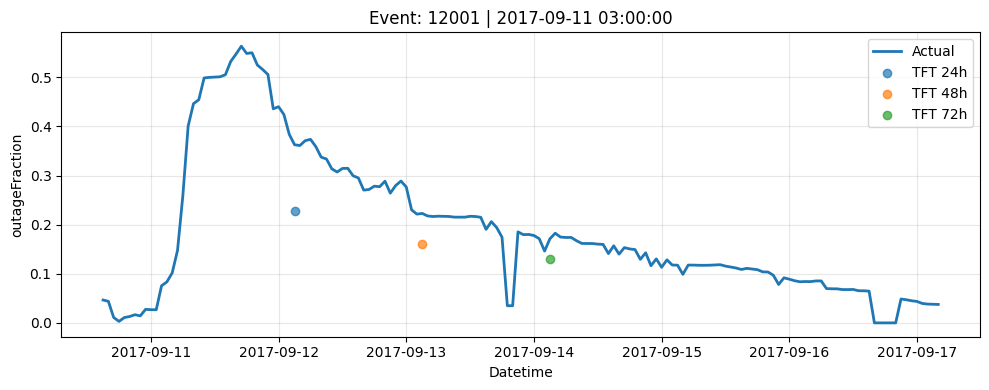

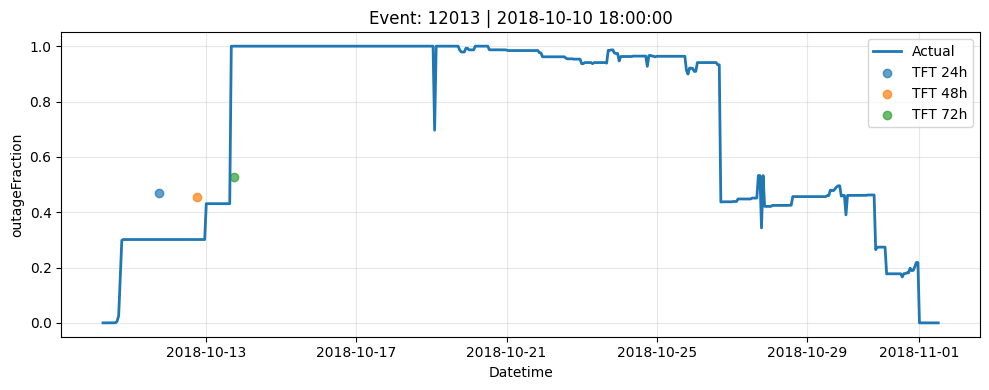

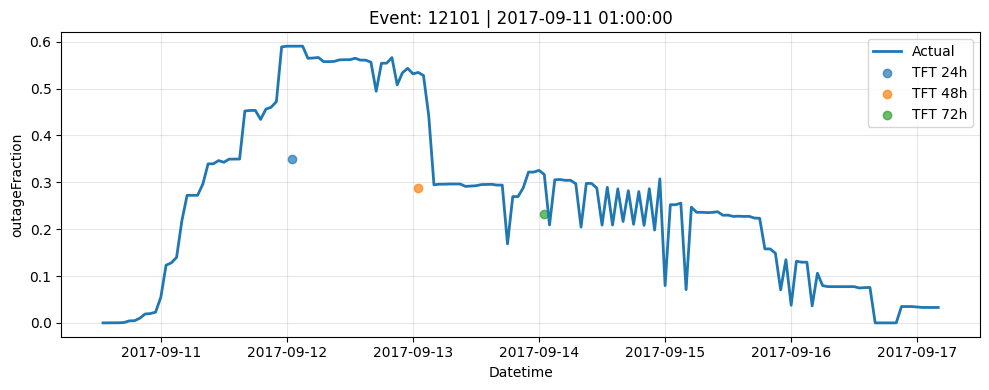

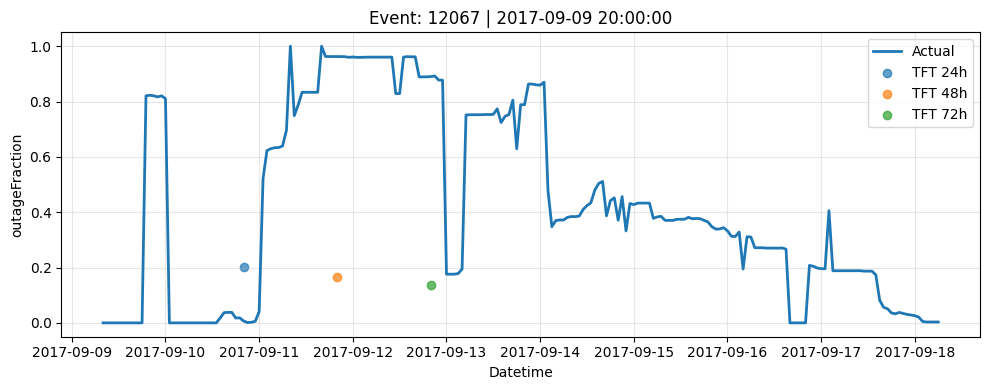

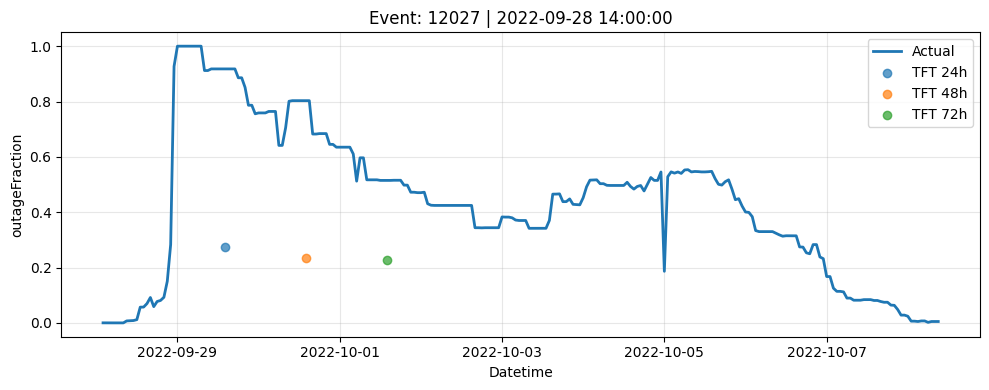

In [30]:
for _, row in sample_events.iterrows():
    fips = row["CountyFIPS"]
    event_start = row["event_start"]

    # Full true series
    ev = model_df[
        (model_df["CountyFIPS"] == fips) &
        (model_df["event_start"] == event_start)
    ].copy()

    ev = ev.sort_values("datetime")

    # Corresponding TFT predictions
    preds = tft_eval_df[
        (tft_eval_df["CountyFIPS"] == fips) &
        (tft_eval_df["event_start"] == event_start)
    ].copy()

    # Compute prediction timestamps
    preds["target_datetime"] = (
        preds["event_start"] +
        pd.to_timedelta(preds["forecast_horizon_hours"], unit="h")
    )

    # Plot
    plt.figure(figsize=(10, 4))

    # True trajectory
    plt.plot(ev["datetime"], ev["outageFraction"], label="Actual", linewidth=2)

    # Predictions by horizon
    for h, grp in preds.groupby("forecast_horizon_hours"):
        plt.scatter(
            grp["target_datetime"],
            grp["y_pred"],
            label=f"TFT {h}h",
            alpha=0.7
        )

    plt.title(f"Event: {fips} | {event_start}")
    plt.xlabel("Datetime")
    plt.ylabel("outageFraction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14) Event-level split and rolling-origin TFT setup

This section retrains the TFT on an event-level split and then generates rolling-origin forecast paths on held-out validation events. It leaves the earlier last-72h split section in place, but the code below is the geometry to use for the path plots.


In [31]:
# Event-level split for rolling-origin evaluation.
EVENT_HOLDOUT_FRAC = 0.20
RNG_SEED = 42
ORIGIN_STRIDE_HOURS = 12
QUANTILES = [0.1, 0.5, 0.9]

# Reuse the already prepared modelling frame from earlier cells.
model_frame = df.copy()
model_frame['event_id'] = model_frame['event_id'].astype(str)
if 'CountyFIPS' in model_frame.columns:
    model_frame['CountyFIPS'] = model_frame['CountyFIPS'].astype(str).str.zfill(5)
if 'datetime' in model_frame.columns:
    model_frame['datetime'] = pd.to_datetime(model_frame['datetime'])
if 'event_start' in model_frame.columns:
    model_frame['event_start'] = pd.to_datetime(model_frame['event_start'])

all_event_ids = sorted(model_frame['event_id'].dropna().unique().tolist())
rng = np.random.default_rng(RNG_SEED)
n_val_events = max(1, int(round(len(all_event_ids) * EVENT_HOLDOUT_FRAC)))
val_event_ids = sorted(rng.choice(all_event_ids, size=n_val_events, replace=False).tolist())
train_event_ids = [eid for eid in all_event_ids if eid not in set(val_event_ids)]

event_train_df = model_frame[model_frame['event_id'].isin(train_event_ids)].copy()
event_val_df = model_frame[model_frame['event_id'].isin(val_event_ids)].copy()

event_train_df = event_train_df.sort_values(['series_id', 'time_idx']).reset_index(drop=True)
event_val_df = event_val_df.sort_values(['series_id', 'time_idx']).reset_index(drop=True)

print(f'Total events: {len(all_event_ids)}')
print(f'Train events: {len(train_event_ids)}')
print(f'Validation events: {len(val_event_ids)}')
print(f'Train rows: {len(event_train_df):,}')
print(f'Validation rows: {len(event_val_df):,}')
print(f'Train series: {event_train_df["series_id"].nunique():,}')
print(f'Validation series: {event_val_df["series_id"].nunique():,}')

event_train_df.head()


Total events: 61
Train events: 49
Validation events: 12
Train rows: 11,638
Validation rows: 2,704
Train series: 49
Validation series: 12


,event_id,storm,geoid,county,datetime,event_start,duration_hours,gust_mps,wind_speed_mps,precip_mm,...,persistence_24h,persistence_48h,persistence_72h,series_id,time_idx,hour,dayofweek,month,dayofyear,cutoff
0,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 15:00:00,2017-09-11 03:00:00,134,9.545648,6.145859,2.925622,...,NaN,NaN,NaN,12001_2017-09-11 03:00:00__12001,0,15,6,9,253,85
1,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 16:00:00,2017-09-11 03:00:00,134,10.602325,7.331592,3.961323,...,NaN,NaN,NaN,12001_2017-09-11 03:00:00__12001,1,16,6,9,253,85
2,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 17:00:00,2017-09-11 03:00:00,134,12.677439,7.569997,3.951933,...,NaN,NaN,NaN,12001_2017-09-11 03:00:00__12001,2,17,6,9,253,85
3,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 18:00:00,2017-09-11 03:00:00,134,13.805998,7.402843,3.323243,...,NaN,NaN,NaN,12001_2017-09-11 03:00:00__12001,3,18,6,9,253,85
4,12001_2017-09-11 03:00:00,2017242N16333,12001,Alachua,2017-09-10 19:00:00,2017-09-11 03:00:00,134,18.680332,8.316379,3.520969,...,NaN,NaN,NaN,12001_2017-09-11 03:00:00__12001,4,19,6,9,253,85


## 15) Build the TFT datasets

The model uses the same covariates as before. The validation dataset is one prediction window per held-out series and is used only to monitor training.


In [36]:
target_col = 'outageFraction'

# Keep the covariates already chosen earlier in the notebook.
# These include calendar variables and weather covariates if present.
assert 'known_reals' in globals(), 'known_reals was not defined earlier in the notebook.'
assert 'static_categoricals' in globals(), 'static_categoricals was not defined earlier in the notebook.'

from pytorch_forecasting.data.encoders import NaNLabelEncoder

categorical_encoders = {
    "series_id": NaNLabelEncoder(add_nan=True),
    "storm": NaNLabelEncoder(add_nan=True),
    "county": NaNLabelEncoder(add_nan=True),
    "CountyFIPS": NaNLabelEncoder(add_nan=True),
} # recommended fix ^ not sure if this will work

train_ds = TimeSeriesDataSet(
    event_train_df,
    time_idx="time_idx",
    target=target_col,
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    min_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    categorical_encoders=categorical_encoders,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

val_ds = TimeSeriesDataSet.from_dataset(
    train_ds,
    event_val_df,
    predict=True,
    stop_randomization=True,
)

batch_size = 64
train_loader = train_ds.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = val_ds.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(train_ds)
print(f'Train samples: {len(train_ds)}')
print(f'Validation samples: {len(val_ds)}')


TimeSeriesDataSet[length=4631](
	time_idx='time_idx',
	target='outageFraction',
	group_ids=['series_id'],
	weight=None,
	max_encoder_length=72,
	min_encoder_length=72,
	min_prediction_idx=0,
	min_prediction_length=72,
	max_prediction_length=72,
	static_categoricals=['storm', 'county', 'CountyFIPS'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['outageFraction'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=True,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['series_id'],
	center=True,
	scale_by_group=False,
	transformation=None,
	method_kwargs={}
),
	categorical_encoders={'series_id': NaNLabelEncoder(add_nan=True

In [37]:
print(static_categoricals)
print(known_reals)
print(train_ds.categorical_encoders)

['storm', 'county', 'CountyFIPS']
['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c']
{'series_id': NaNLabelEncoder(add_nan=True, warn=True), 'storm': NaNLabelEncoder(add_nan=True, warn=True), 'county': NaNLabelEncoder(add_nan=True, warn=True), 'CountyFIPS': NaNLabelEncoder(add_nan=True, warn=True)}


^ The fix is to tell PyTorch Forecasting to tolerate unseen categories for the relevant categorical fields.
If you want the cleaner modelling choice, the alternative is to stop using series_id as a learned categorical feature and use a more reusable grouping variable like CountyFIPS. But that changes the setup more than necessary right now.

^ this is intuitively what we thought about before anyway

Same with:
* series_id (group id)
* storm
* county
* CountyFIPS

Note:
* series_id: always unseen in validation → effectively useless as a learned embedding
* storm: likely unseen → weak signal
* county / CountyFIPS: partially reusable → actually useful

So the model will mostly rely on:
* autoregressive signal (target history)
* weather covariates
* weak spatial signal from county


In [38]:
pl.seed_everything(42, workers=True)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

tft_ro = TemporalFusionTransformer.from_dataset(
    train_ds,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=len(QUANTILES),
    loss=QuantileLoss(quantiles=QUANTILES),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

trainer_ro = pl.Trainer(
    max_epochs=20,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    enable_checkpointing=True,
    enable_progress_bar=True,
    log_every_n_steps=10,
)

trainer_ro.fit(tft_ro, train_dataloaders=train_loader, val_dataloaders=val_loader)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.3 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    240 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     51 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 33.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 549                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


## 17) Rolling-origin helper functions

Each forecast origin is one hour index within a held-out series. For an origin at time t0, the helper truncates the series at t0 + 72h, builds a one-sample prediction dataset, and extracts the 10, 50, and 90 percent quantile forecasts.


In [39]:
def _extract_prediction_array(prediction_obj):
    """Convert a PyTorch Forecasting prediction result into a NumPy array.

    The exact return type varies a bit across pytorch-forecasting versions and
    predict() modes, so this helper handles tensors, tuples, and objects with
    common attributes such as .prediction or .output.
    """
    if isinstance(prediction_obj, tuple) or isinstance(prediction_obj, list):
        prediction_obj = prediction_obj[0]

    for attr in ('prediction', 'output'):
        if hasattr(prediction_obj, attr):
            prediction_obj = getattr(prediction_obj, attr)
            break

    if torch.is_tensor(prediction_obj):
        return prediction_obj.detach().cpu().numpy()

    return np.asarray(prediction_obj)


def predict_rolling_origin_for_series(series_id: str, origin_stride_hours: int = 12) -> pd.DataFrame:
    """Generate rolling-origin TFT forecasts for one held-out series."""
    series_df = event_val_df.loc[event_val_df['series_id'] == series_id].copy()
    series_df = series_df.sort_values('time_idx').reset_index(drop=True)

    if len(series_df) < (max_encoder_length + max_prediction_length):
        return pd.DataFrame()

    origin_indices = range(
        max_encoder_length - 1,
        len(series_df) - max_prediction_length,
        origin_stride_hours,
    )

    rows = []
    for origin_idx in origin_indices:
        origin_row = series_df.iloc[origin_idx]
        cutoff_idx = origin_idx + max_prediction_length

        if cutoff_idx >= len(series_df):
            continue

        # Truncate at origin + forecast horizon so the last decoder window is
        # exactly the 72-hour forecast block after the origin.
        sub_df = series_df.iloc[:cutoff_idx + 1].copy()
        if len(sub_df) < (max_encoder_length + max_prediction_length):
            continue

        sample_ds = TimeSeriesDataSet.from_dataset(
            train_ds,
            sub_df,
            predict=True,
            stop_randomization=True,
        )
        sample_loader = sample_ds.to_dataloader(train=False, batch_size=1, num_workers=0)

        raw_pred = tft_ro.predict(
            sample_loader,
            mode='quantiles',
            trainer_kwargs=dict(accelerator=accelerator),
        )
        pred_array = _extract_prediction_array(raw_pred)

        # Expect shape [batch, horizon, n_quantiles].
        if pred_array.ndim == 2:
            pred_array = pred_array[None, :, :]
        if pred_array.shape[-1] != len(QUANTILES):
            raise ValueError(
                f'Expected {len(QUANTILES)} quantiles, got array with shape {pred_array.shape}.'
            )

        pred_array = pred_array[0]

        target_df = series_df.iloc[origin_idx + 1: cutoff_idx + 1].copy()
        if len(target_df) != max_prediction_length:
            continue

        persistence_value = float(origin_row[target_col])

        for horizon_step in range(1, max_prediction_length + 1):
            q10, q50, q90 = pred_array[horizon_step - 1, :]
            target_row = target_df.iloc[horizon_step - 1]
            rows.append({
                'series_id': series_id,
                'event_id': origin_row['event_id'],
                'storm': origin_row.get('storm', None),
                'CountyFIPS': origin_row.get('CountyFIPS', None),
                'county': origin_row.get('county', None),
                'event_start': origin_row.get('event_start', None),
                'origin_datetime': origin_row['datetime'],
                'origin_time_idx': int(origin_row['time_idx']),
                'forecast_horizon_hours': int(horizon_step),
                'target_datetime': target_row['datetime'],
                'hours_since_event_start_at_origin': int(origin_row['time_idx']),
                'y_true': float(target_row[target_col]),
                'persistence_pred': persistence_value,
                'tft_q10': float(q10),
                'tft_q50': float(q50),
                'tft_q90': float(q90),
            })

    return pd.DataFrame(rows)


## 18) Build rolling-origin predictions for five held-out series

The plots below use five validation series sampled from the held-out events. Each forecast origin is spaced 12 hours apart.


In [40]:
selected_series_ids = (
    event_val_df[['series_id', 'event_id', 'storm', 'CountyFIPS']]
    .drop_duplicates()
    .sample(n=min(5, event_val_df['series_id'].nunique()), random_state=42)['series_id']
    .tolist()
)

rolling_origin_frames = []
for series_id in selected_series_ids:
    ro_df = predict_rolling_origin_for_series(series_id, origin_stride_hours=ORIGIN_STRIDE_HOURS)
    if not ro_df.empty:
        rolling_origin_frames.append(ro_df)

if not rolling_origin_frames:
    raise ValueError('No rolling-origin forecasts were generated. Check the held-out series lengths.')

rolling_origin_eval_df = pd.concat(rolling_origin_frames, ignore_index=True)
rolling_origin_eval_df.head()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

,series_id,event_id,storm,CountyFIPS,county,event_start,origin_datetime,origin_time_idx,forecast_horizon_hours,target_datetime,hours_since_event_start_at_origin,y_true,persistence_pred,tft_q10,tft_q50,tft_q90
0,12123_2017-09-11 02:00:00__12123,12123_2017-09-11 02:00:00,2017242N16333,12123,Taylor,2017-09-11 02:00:00,2017-09-13 13:00:00,71,1,2017-09-13 14:00:00,71,0.295942,0.296491,0.501644,0.576369,0.673165
1,12123_2017-09-11 02:00:00__12123,12123_2017-09-11 02:00:00,2017242N16333,12123,Taylor,2017-09-11 02:00:00,2017-09-13 13:00:00,71,2,2017-09-13 15:00:00,71,0.302143,0.296491,0.509561,0.593064,0.693949
2,12123_2017-09-11 02:00:00__12123,12123_2017-09-11 02:00:00,2017242N16333,12123,Taylor,2017-09-11 02:00:00,2017-09-13 13:00:00,71,3,2017-09-13 16:00:00,71,0.335741,0.296491,0.510864,0.599159,0.706068
3,12123_2017-09-11 02:00:00__12123,12123_2017-09-11 02:00:00,2017242N16333,12123,Taylor,2017-09-11 02:00:00,2017-09-13 13:00:00,71,4,2017-09-13 17:00:00,71,0.300024,0.296491,0.509007,0.594596,0.699986
4,12123_2017-09-11 02:00:00__12123,12123_2017-09-11 02:00:00,2017242N16333,12123,Taylor,2017-09-11 02:00:00,2017-09-13 13:00:00,71,5,2017-09-13 18:00:00,71,0.149494,0.296491,0.504317,0.584409,0.681613


## 19) Horizon-wise metrics for the rolling-origin paths

Use the TFT median for point metrics and compare it directly with the persistence baseline on the same rows.


In [41]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }

rolling_tft_metrics_df = (
    rolling_origin_eval_df
    .groupby('forecast_horizon_hours')
    .apply(lambda g: pd.Series(regression_metrics(g['y_true'], g['tft_q50'])))
    .reset_index()
)

rolling_persistence_metrics_df = (
    rolling_origin_eval_df
    .groupby('forecast_horizon_hours')
    .apply(lambda g: pd.Series(regression_metrics(g['y_true'], g['persistence_pred'])))
    .reset_index()
)

rolling_comparison_df = rolling_tft_metrics_df.merge(
    rolling_persistence_metrics_df,
    on='forecast_horizon_hours',
    suffixes=('_tft', '_persistence'),
)

rolling_comparison_df


,forecast_horizon_hours,mae_tft,rmse_tft,r2_tft,mae_persistence,rmse_persistence,r2_persistence
0,1,0.153281,0.188895,-0.336819,0.025759,0.063123,0.850720
1,2,0.164042,0.209425,-0.636023,0.030574,0.069655,0.819015
2,3,0.191321,0.233969,-0.851902,0.049369,0.086222,0.748502
3,4,0.172832,0.202003,-0.771987,0.027683,0.039171,0.933371
4,5,0.189585,0.223405,-0.813183,0.047756,0.073764,0.802326
...,...,...,...,...,...,...,...
67,68,0.155824,0.174404,-0.581907,0.277280,0.287239,-3.290935
68,69,0.145844,0.164622,-0.509749,0.276089,0.283932,-3.491125
69,70,0.139055,0.158205,-0.480988,0.273658,0.279006,-3.606177
70,71,0.137503,0.153450,-0.319738,0.283160,0.287950,-3.647137


## 20) Rolling-origin path plots for five held-out series

Each panel shows the full actual outage trajectory for one series, together with TFT forecast paths started every 12 hours. The shaded region is the 10 to 90 percent interval and the central line is the median forecast. Persistence is overlaid as a flat reference from each origin.


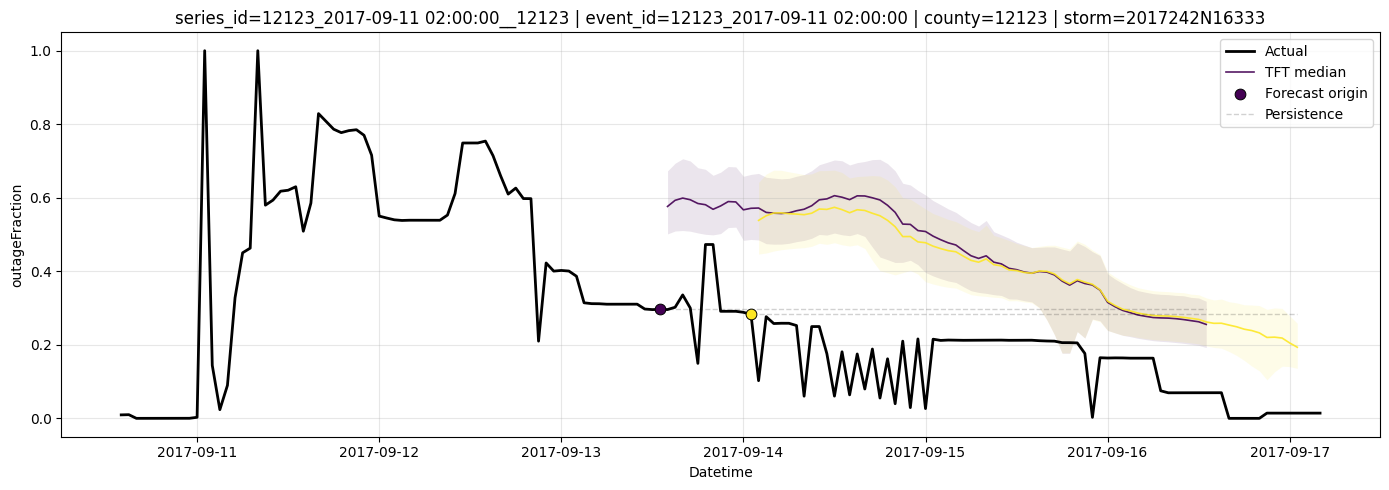

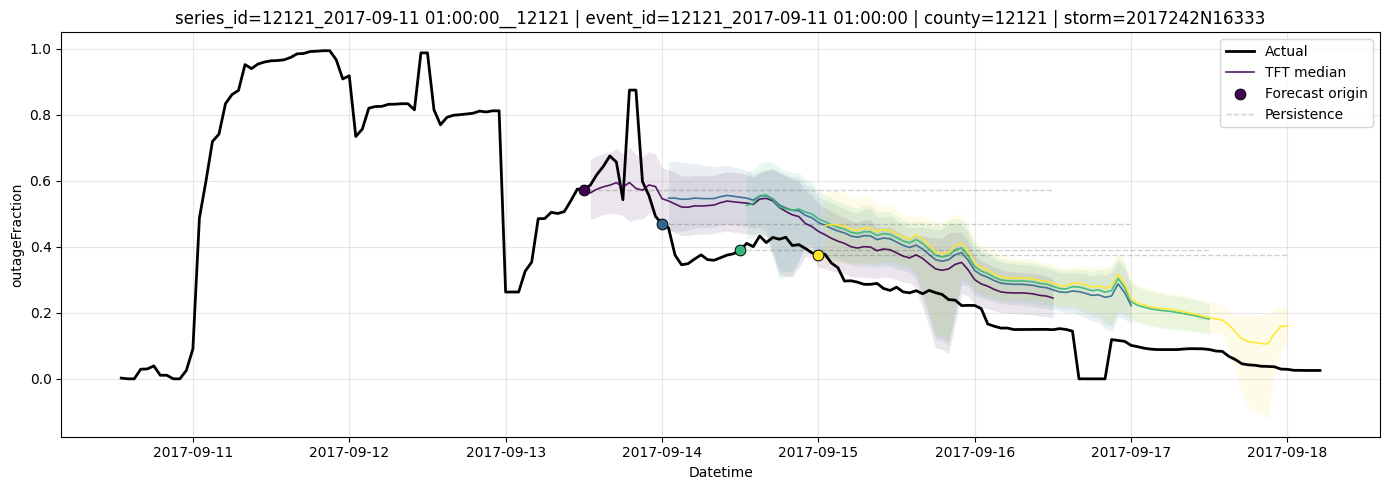

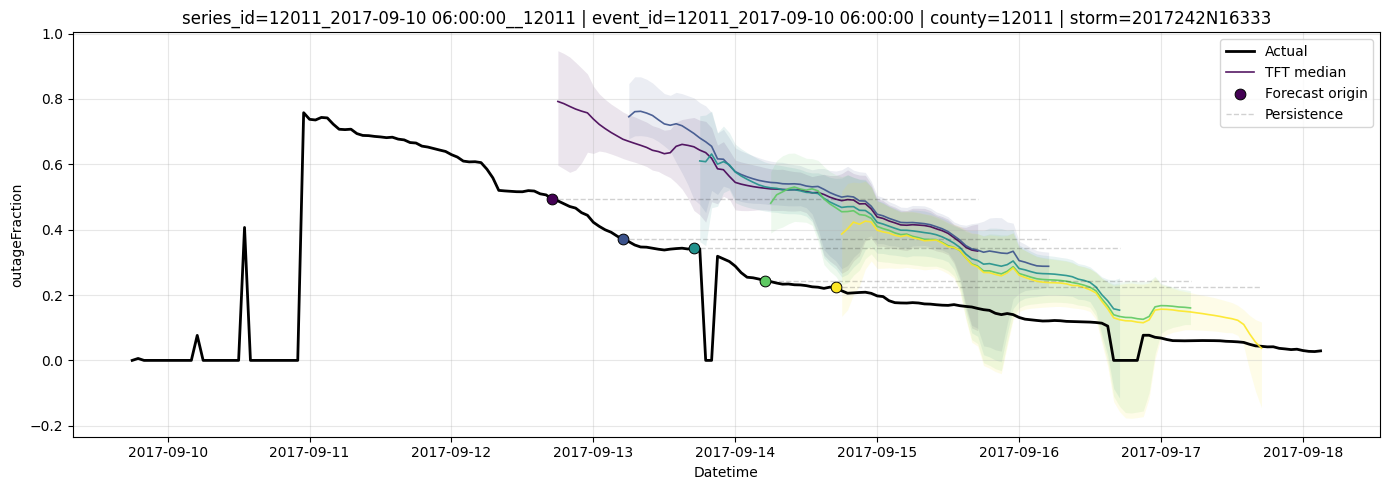

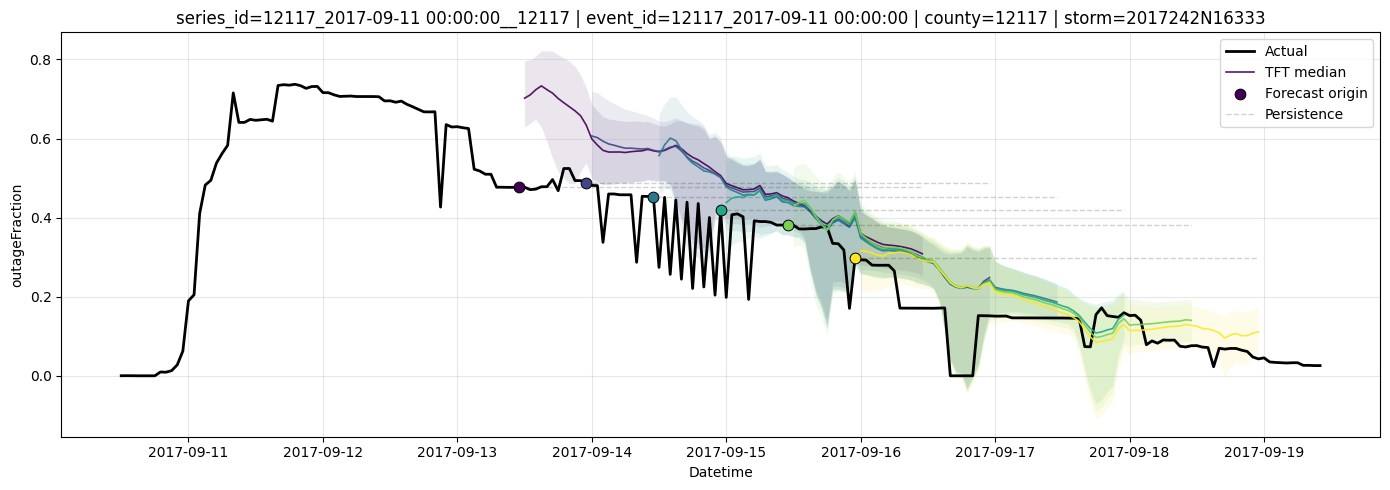

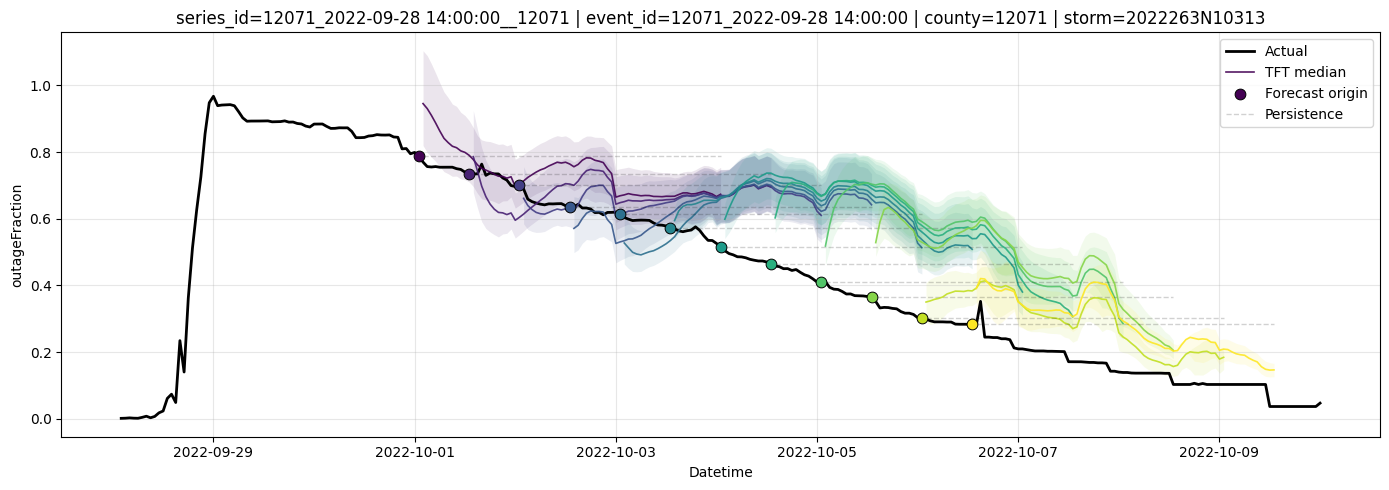

In [45]:
from matplotlib.colors import Normalize
import pandas as pd
import matplotlib.pyplot as plt

def plot_series_rolling_paths(series_id: str) -> None:
    series_df = event_val_df.loc[event_val_df['series_id'] == series_id].copy()
    series_df = series_df.sort_values('time_idx').reset_index(drop=True)

    ro_df = rolling_origin_eval_df.loc[rolling_origin_eval_df['series_id'] == series_id].copy()
    ro_df = ro_df.sort_values(['origin_datetime', 'forecast_horizon_hours'])

    if series_df.empty or ro_df.empty:
        return

    event_id = series_df['event_id'].iloc[0]
    storm = series_df['storm'].iloc[0] if 'storm' in series_df.columns else 'unknown'
    county = series_df['CountyFIPS'].iloc[0] if 'CountyFIPS' in series_df.columns else 'unknown'

    origins = list(ro_df['origin_datetime'].drop_duplicates().sort_values())
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=max(1, len(origins) - 1))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(series_df['datetime'], series_df[target_col], color='black', linewidth=2, label='Actual')

    for j, origin in enumerate(origins):
        one = ro_df.loc[ro_df['origin_datetime'] == origin].sort_values('forecast_horizon_hours')
        color = cmap(norm(j))
        x = pd.to_datetime(one['target_datetime'])

        ax.fill_between(
            x,
            one['tft_q10'].to_numpy(dtype=float),
            one['tft_q90'].to_numpy(dtype=float),
            color=color,
            alpha=0.10,
            linewidth=0,
        )

        ax.plot(
            x,
            one['tft_q50'].to_numpy(dtype=float),
            color=color,
            linewidth=1.2,
            alpha=0.90,
            label='TFT median' if j == 0 else None,
        )

        # Forecast origin marker
        origin_idx = (pd.to_datetime(series_df['datetime']) - pd.to_datetime(origin)).abs().idxmin()
        y0 = float(series_df.loc[origin_idx, target_col])
        x0 = pd.to_datetime(series_df.loc[origin_idx, 'datetime'])

        ax.scatter(
            x0,
            y0,
            color=color,
            s=60,
            marker='o',
            edgecolor='black',
            linewidth=0.7,
            zorder=10,
            label='Forecast origin' if j == 0 else None,
        )

        ax.plot(
            x,
            one['persistence_pred'].to_numpy(dtype=float),
            color='black',
            linestyle='--',
            linewidth=1.0,
            alpha=0.18,
            label='Persistence' if j == 0 else None,
        )

    ax.set_title(f'series_id={series_id} | event_id={event_id} | county={county} | storm={storm}')
    ax.set_xlabel('Datetime')
    ax.set_ylabel('outageFraction')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


for sid in selected_series_ids:
    plot_series_rolling_paths(sid)

Variable importance:
- first, need to rerun since apparently val_ds was not created from the exact train_ds used to train tft *or* tft was not trained on the same train_ds

In [55]:
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# Rebuild categorical encoders so unseen validation categories do not crash embedding lookup.
categorical_encoders = {
    "series_id": NaNLabelEncoder(add_nan=True),
    "storm": NaNLabelEncoder(add_nan=True),
    "county": NaNLabelEncoder(add_nan=True),
    "CountyFIPS": NaNLabelEncoder(add_nan=True),
}

# Recreate the training dataset from the current train split.
training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target=target_col,
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    min_prediction_length=max_prediction_length,
    static_categoricals=static_categoricals,
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=[target_col],
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    categorical_encoders=categorical_encoders,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

# Build validation data from the exact same training dataset object.
validation = TimeSeriesDataSet.from_dataset(
    training,
    full_df,
    predict=True,
    stop_randomization=True,
)

batch_size = 64
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(training)
print("Training samples:", len(training))
print("Validation samples:", len(validation))

# Recreate and refit the TFT model on the rebuilt datasets.
pl.seed_everything(42, workers=True)
accelerator = "gpu" if torch.cuda.is_available() else "cpu"

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    optimizer="adam",
    log_interval=10,
    reduce_on_plateau_patience=4,
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    enable_checkpointing=True,
    enable_progress_bar=True,
    log_every_n_steps=10,
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

Seed set to 42


TimeSeriesDataSet[length=2444](
	time_idx='time_idx',
	target='outageFraction',
	group_ids=['series_id'],
	weight=None,
	max_encoder_length=72,
	min_encoder_length=72,
	min_prediction_idx=0,
	min_prediction_length=72,
	max_prediction_length=72,
	static_categoricals=['storm', 'county', 'CountyFIPS'],
	static_reals=None,
	time_varying_known_categoricals=None,
	time_varying_known_reals=['time_idx', 'hour', 'dayofweek', 'month', 'dayofyear', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['outageFraction'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=True,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['series_id'],
	center=True,
	scale_by_group=False,
	transformation=None,
	method_kwargs={}
),
	categorical_encoders={'series_id': NaNLabelEncoder(add_nan=True

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.7 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    240 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 33.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 549                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


may need to patch cell 15 so it includes the encoders? thought it already did

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


attention


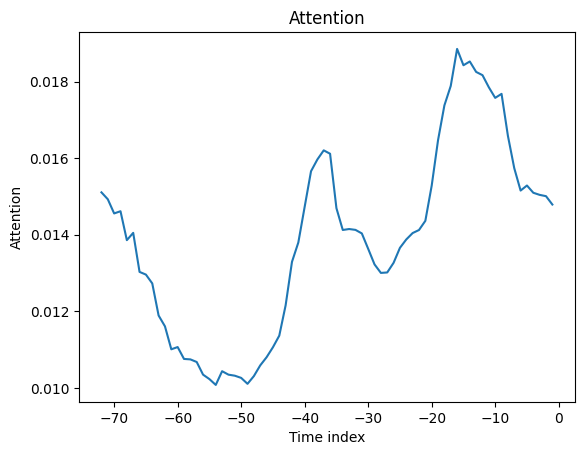

static_variables


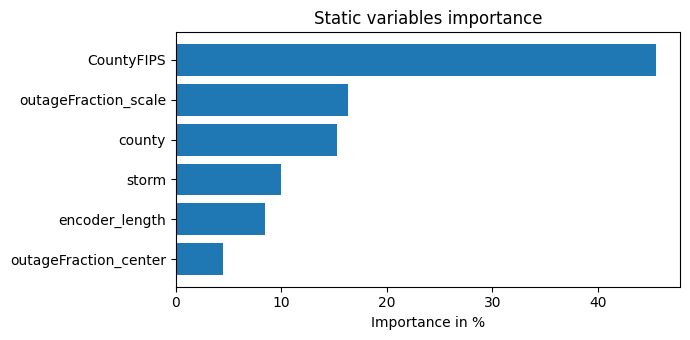

encoder_variables


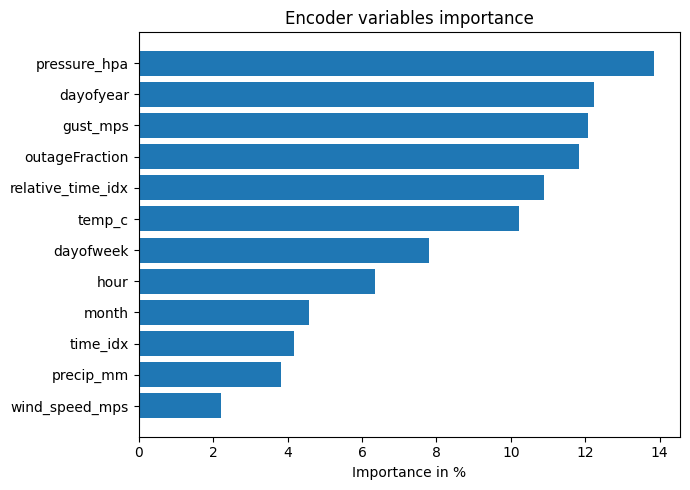

decoder_variables


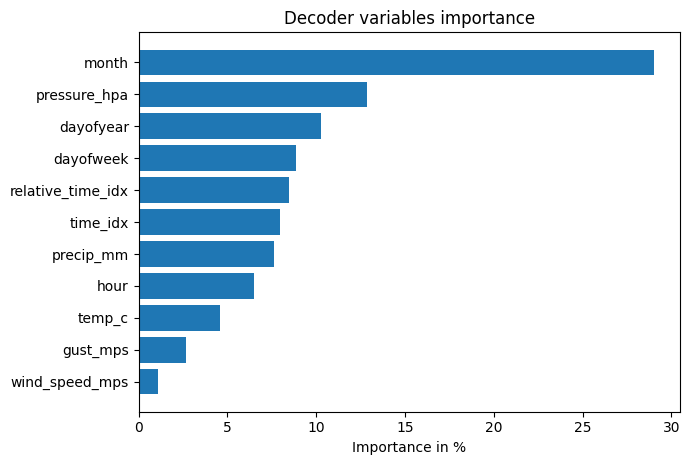

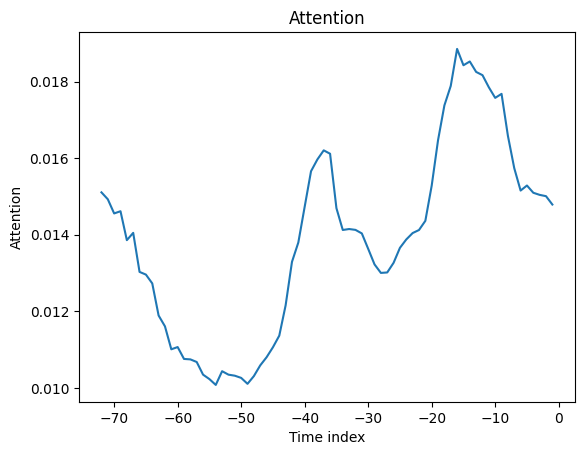

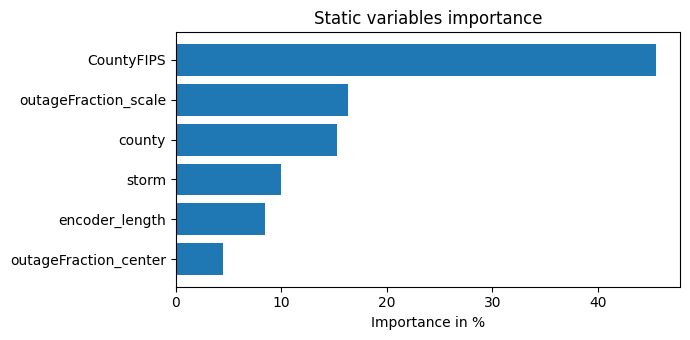

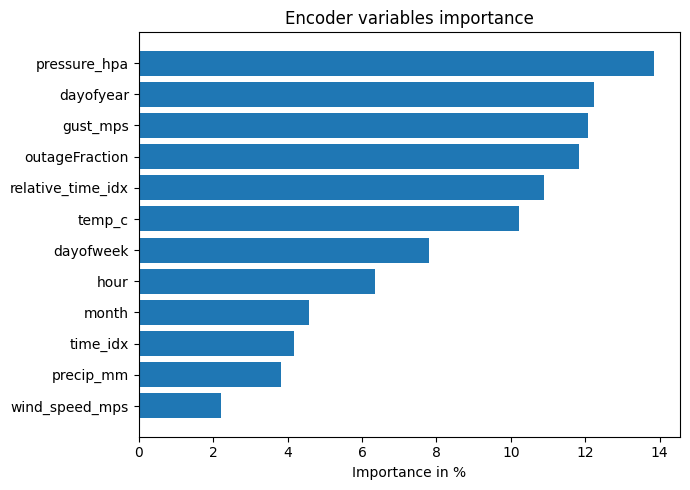

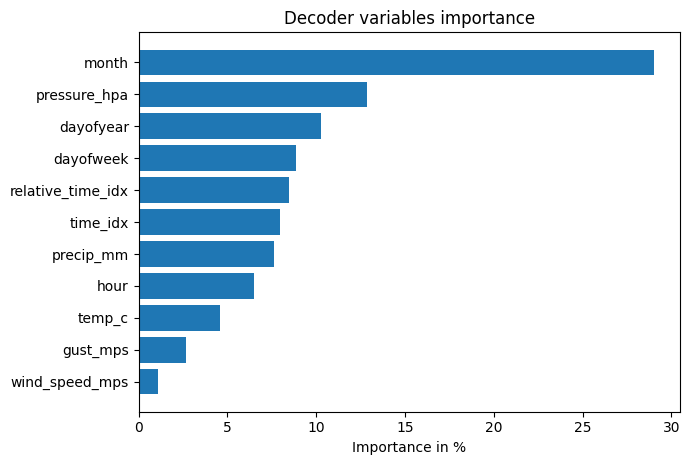

In [ ]:
# interp:

from IPython.display import display

# Raw predictions on the validation loader
raw = tft.predict(
    val_loader,
    mode="raw",
    return_x=True,
    return_y=True,
)

# Handle the common return shapes across PyTorch Forecasting versions
raw_pred = raw.output if hasattr(raw, "output") else raw[0]

# TFT interpretation object
interpretation = tft.interpret_output(raw_pred, reduction="sum")

# Built-in plots
figs = tft.plot_interpretation(interpretation)

for name, fig in figs.items():
    print(name)
    display(fig)

In [57]:
# Optional, to inspect the actual weights numerically:
for k, v in interpretation.items():
    try:
        print(k, v.detach().cpu().numpy())
    except Exception:
        print(k, v)

attention [0.92143893 0.91044873 0.8878397  0.89137256 0.8452794  0.8569047
 0.7946803  0.7904074  0.7763621  0.7252263  0.70796704 0.67137444
 0.6749423  0.6560079  0.65531385 0.6511361  0.63098395 0.62390685
 0.6146137  0.6364683  0.63097024 0.62930703 0.62581193 0.6163594
 0.6286658  0.6457336  0.6587006  0.6746049  0.6931093  0.74140614
 0.8106798  0.841512   0.8984481  0.9550885  0.9738445  0.9883576
 0.98294044 0.89624906 0.8614906  0.863002   0.86164045 0.8559982
 0.8314752  0.80661535 0.793092   0.7937949  0.8091678  0.8330372
 0.84639657 0.8565878  0.86142164 0.87603974 0.9320582  1.0045707
 1.0599853  1.0909901  1.1499648  1.1239369  1.1299398  1.11332
 1.1081376  1.0887903  1.0719632  1.0783627  1.0115552  0.9600037
 0.92429113 0.9323272  0.92079115 0.9174248  0.91535044 0.9020143 ]
static_variables [ 6.0718145  9.3234005 27.77167    5.1672096  2.7289534  9.936954 ]
encoder_variables [2.538743  3.8807788 4.7660093 2.7868834 7.458595  7.3574553 1.3479542
 2.325657  8.450258  